# AAL (Australian Apparal Limited) — Q4 2020 Sales Analysis

**Objective:** Analyze Q4 2020 sales data on a state-by-state basis to help AAL's Sales & Marketing leadership:
1. Identify states generating the highest revenues
2. Develop data-driven sales programs for lower-revenue states

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('AusApparalSales4thQrt2020.csv')

# Strip leading/trailing whitespace from string columns
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print('Shape:', df.shape)
df.head(10)

Shape: (7560, 6)


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
5,1-Oct-2020,Afternoon,WA,Men,10,25000
6,1-Oct-2020,Afternoon,WA,Women,3,7500
7,1-Oct-2020,Afternoon,WA,Seniors,11,27500
8,1-Oct-2020,Evening,WA,Kids,15,37500
9,1-Oct-2020,Evening,WA,Men,15,37500


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB


In [4]:
df.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


## 3. Data Cleaning & Feature Engineering

In [5]:
# Check for nulls
print('Missing values per column:')
print(df.isnull().sum())

# Check for duplicates
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Duplicate rows: 0


In [6]:
# Convert Date to datetime and extract month
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month_name()
df['Month_Num'] = df['Date'].dt.month

# Verify unique values per categorical column
for col in ['State', 'Group', 'Time', 'Month']:
    print(f"{col}: {sorted(df[col].unique())}")

State: ['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
Group: ['Kids', 'Men', 'Seniors', 'Women']
Time: ['Afternoon', 'Evening', 'Morning']
Month: ['December', 'November', 'October']


## 4. State-Level Revenue Analysis

In [7]:
state_sales = (
    df.groupby('State')['Sales']
    .agg(Total_Sales='sum', Avg_Sales='mean', Transactions='count')
    .sort_values('Total_Sales', ascending=False)
    .reset_index()
)
state_sales['Revenue_Share_%'] = (state_sales['Total_Sales'] / state_sales['Total_Sales'].sum() * 100).round(2)
state_sales['Total_Sales_M'] = (state_sales['Total_Sales'] / 1e6).round(2)

print('=== State-Wise Q4 2020 Revenue Summary ===')
state_sales[['State','Total_Sales_M','Revenue_Share_%','Avg_Sales','Transactions']]

=== State-Wise Q4 2020 Revenue Summary ===


,State,Total_Sales_M,Revenue_Share_%,Avg_Sales,Transactions
0,VIC,105.56,31.02,97745.370370,1080
1,NSW,74.97,22.03,69416.666667,1080
2,SA,58.86,17.30,54497.685185,1080
3,QLD,33.42,9.82,30942.129630,1080
4,TAS,22.76,6.69,21074.074074,1080
5,NT,22.58,6.64,20907.407407,1080
6,WA,22.15,6.51,20511.574074,1080


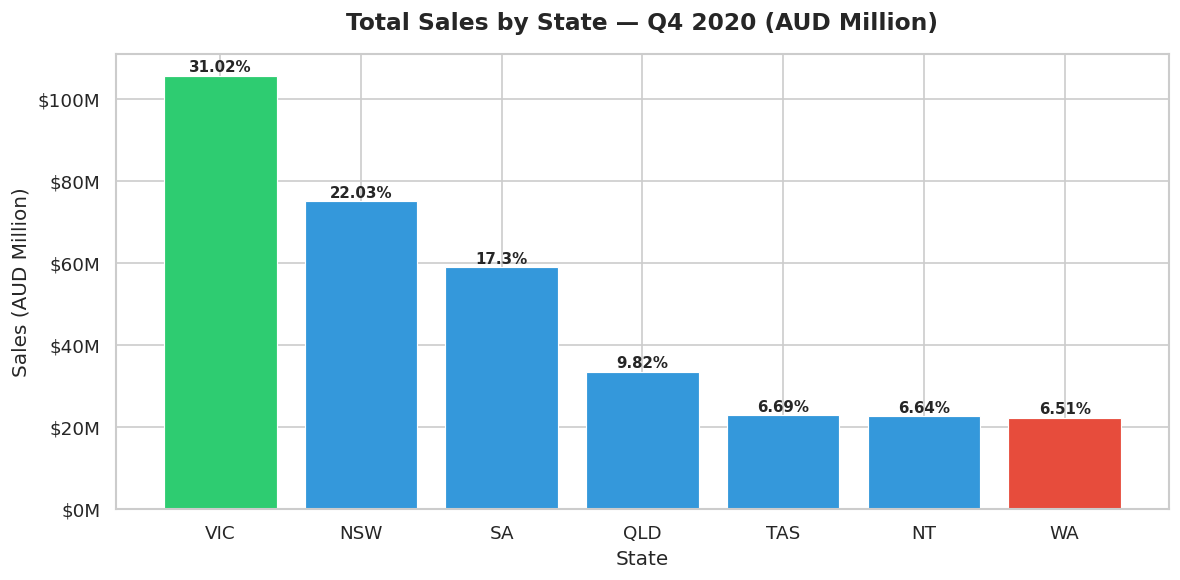

Green = Highest Revenue State | Red = Lowest Revenue State


In [8]:
# Bar chart — Total Sales by State
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if s == state_sales['Total_Sales'].max() else
          '#e74c3c' if s == state_sales['Total_Sales'].min() else '#3498db'
          for s in state_sales['Total_Sales']]

bars = ax.bar(state_sales['State'], state_sales['Total_Sales'] / 1e6, color=colors, edgecolor='white', linewidth=0.7)

for bar, share in zip(bars, state_sales['Revenue_Share_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{share}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Total Sales by State — Q4 2020 (AUD Million)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Sales (AUD Million)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
plt.tight_layout()
plt.savefig('state_total_sales.png', bbox_inches='tight')
plt.show()

print('Green = Highest Revenue State | Red = Lowest Revenue State')

## 5. Customer Group Analysis by State

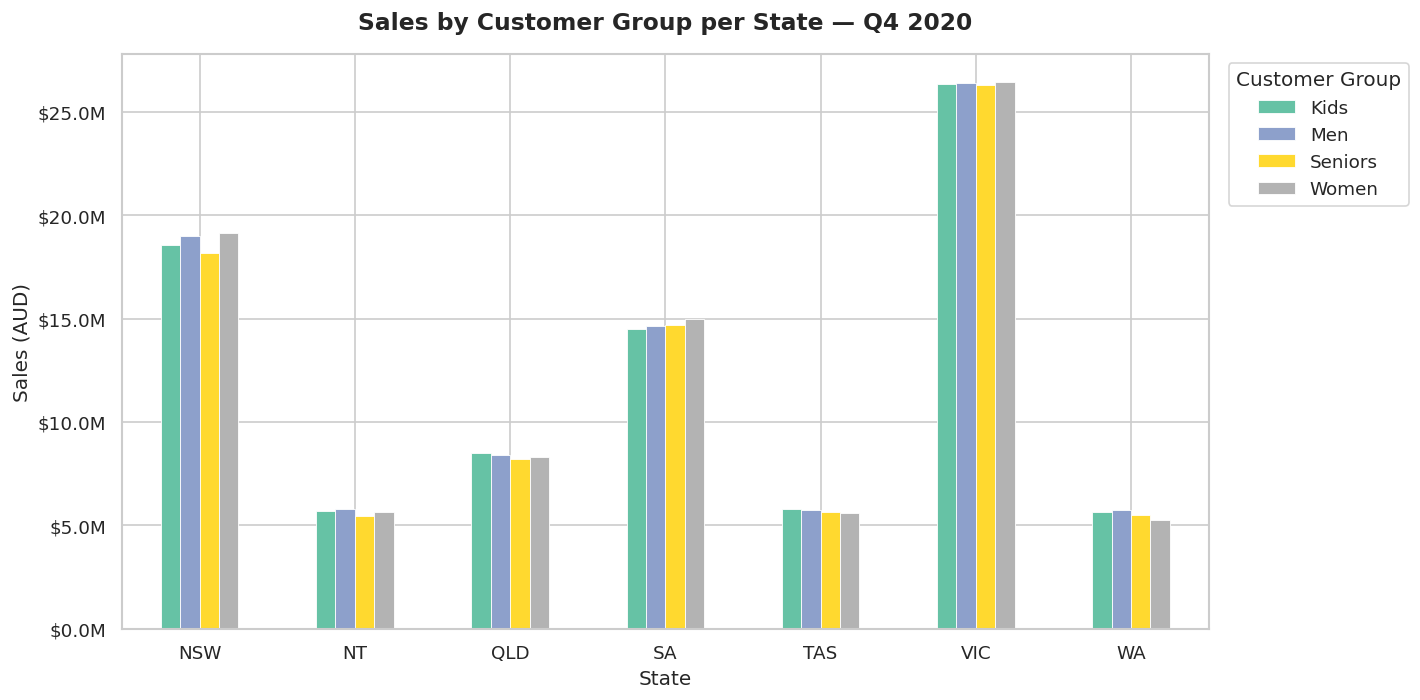

In [9]:
group_state = df.groupby(['State', 'Group'])['Sales'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
group_state.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('Sales by Customer Group per State — Q4 2020', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Sales (AUD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Customer Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('group_by_state.png', bbox_inches='tight')
plt.show()

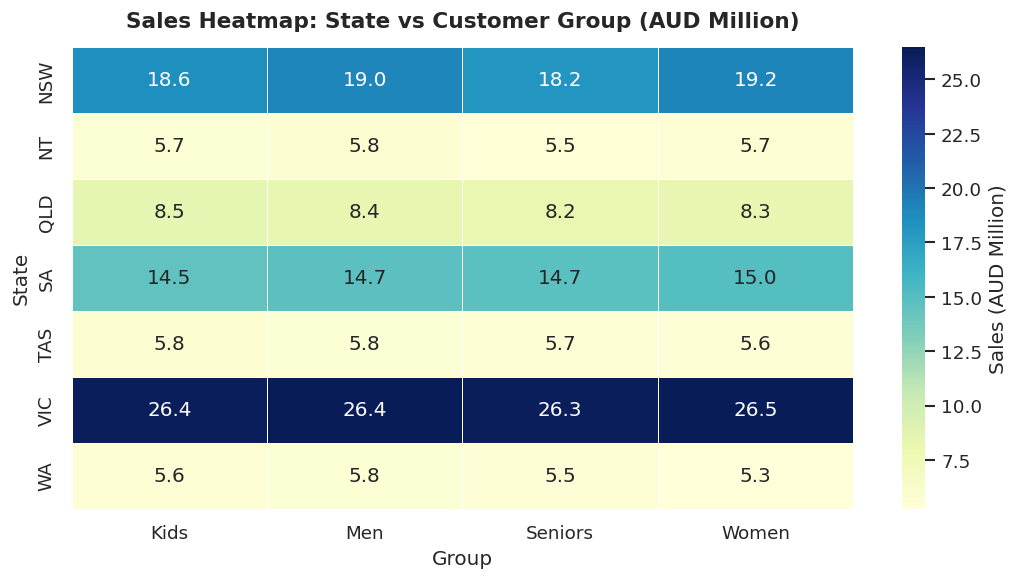

In [10]:
# Heatmap: Sales intensity — State vs Group
pivot = df.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sales (AUD Million)'})
ax.set_title('Sales Heatmap: State vs Customer Group (AUD Million)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('heatmap_state_group.png', bbox_inches='tight')
plt.show()

## 6. Time-of-Day Analysis by State

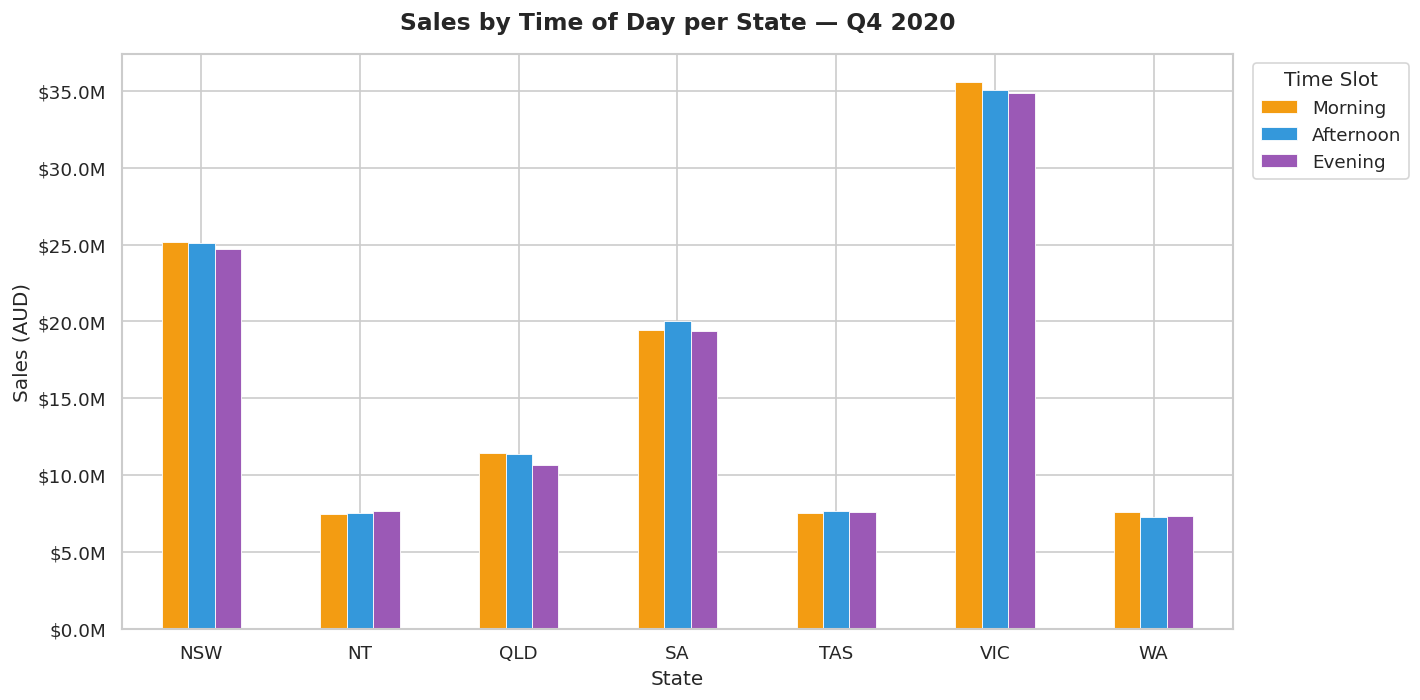

In [11]:
time_order = ['Morning', 'Afternoon', 'Evening']
time_state = df.groupby(['State', 'Time'])['Sales'].sum().unstack()[time_order]

fig, ax = plt.subplots(figsize=(12, 6))
time_state.plot(kind='bar', ax=ax, color=['#f39c12', '#3498db', '#9b59b6'],
                edgecolor='white', linewidth=0.5)
ax.set_title('Sales by Time of Day per State — Q4 2020', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Sales (AUD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Time Slot', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('time_by_state.png', bbox_inches='tight')
plt.show()

## 7. Monthly Trend Analysis

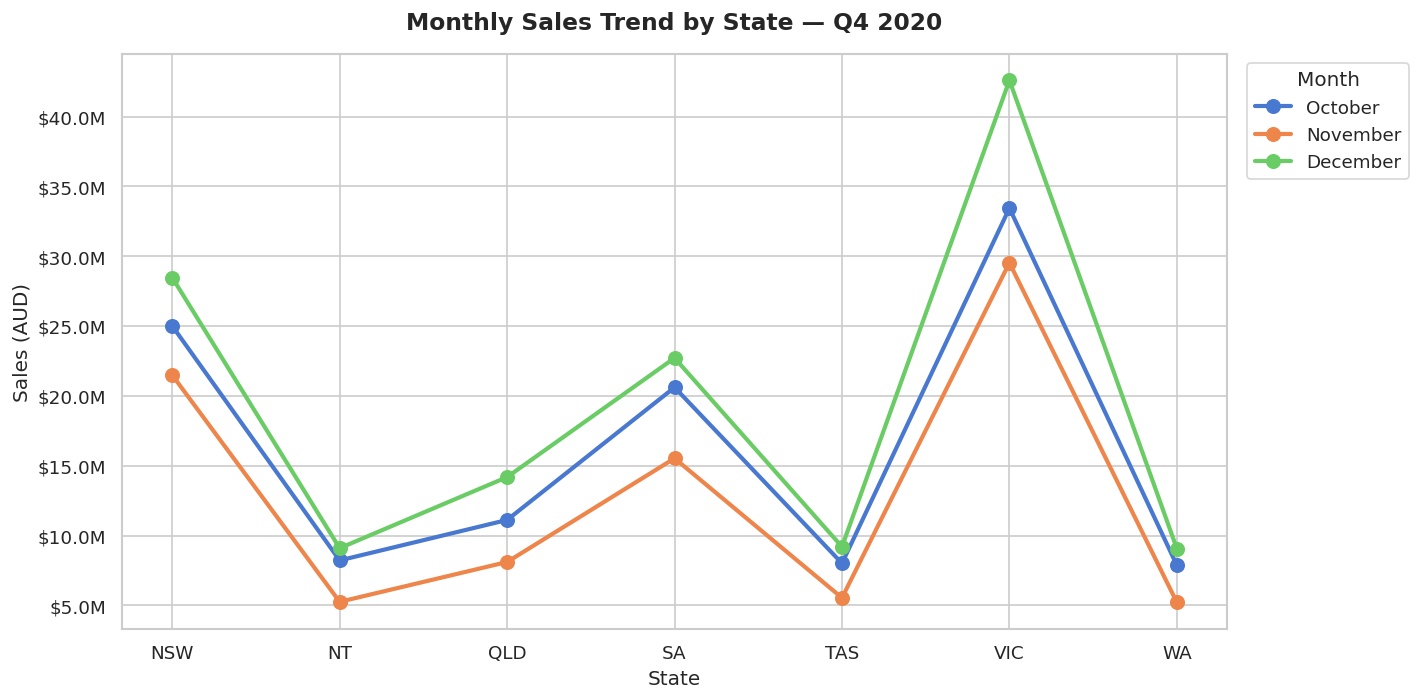

In [12]:
month_order = ['October', 'November', 'December']
monthly_state = df.groupby(['State', 'Month'])['Sales'].sum().unstack()[month_order]

fig, ax = plt.subplots(figsize=(12, 6))
monthly_state.plot(kind='line', ax=ax, marker='o', linewidth=2.5, markersize=8)
ax.set_title('Monthly Sales Trend by State — Q4 2020', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Sales (AUD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Month', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight')
plt.show()

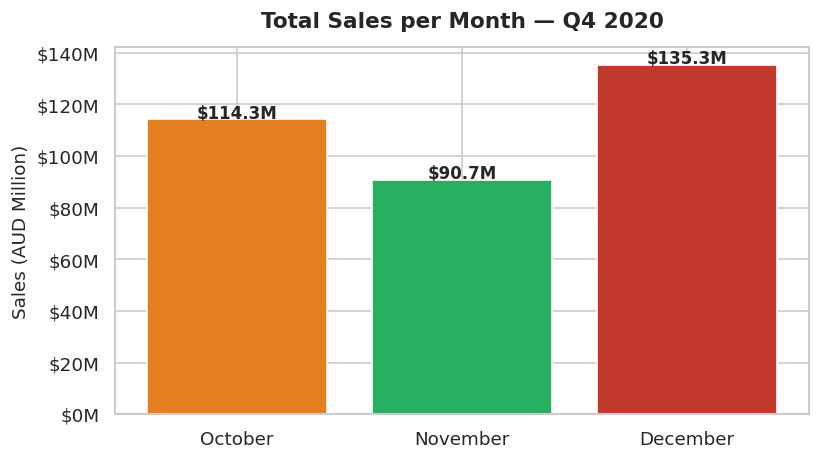

In [13]:
# Overall monthly totals
monthly_total = df.groupby(['Month_Num','Month'])['Sales'].sum().reset_index().sort_values('Month_Num')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(monthly_total['Month'], monthly_total['Sales'] / 1e6,
       color=['#e67e22', '#27ae60', '#c0392b'], edgecolor='white')
ax.set_title('Total Sales per Month — Q4 2020', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Sales (AUD Million)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
for bar, val in zip(ax.patches, monthly_total['Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${val/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_total.png', bbox_inches='tight')
plt.show()

## 8. Revenue Distribution — Box Plot & Pie Chart

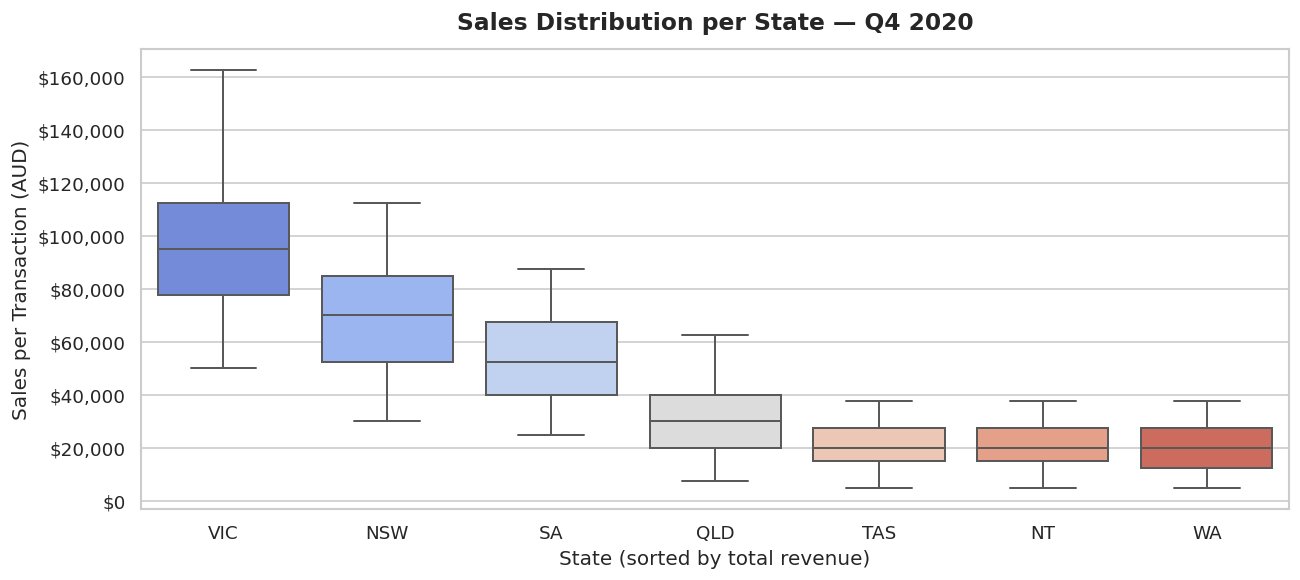

In [14]:
# Box plot — Sales distribution per state
state_order = state_sales['State'].tolist()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='State', y='Sales', order=state_order,
            palette='coolwarm', ax=ax, linewidth=1.2)
ax.set_title('Sales Distribution per State — Q4 2020', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('State (sorted by total revenue)', fontsize=12)
ax.set_ylabel('Sales per Transaction (AUD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('boxplot_state.png', bbox_inches='tight')
plt.show()

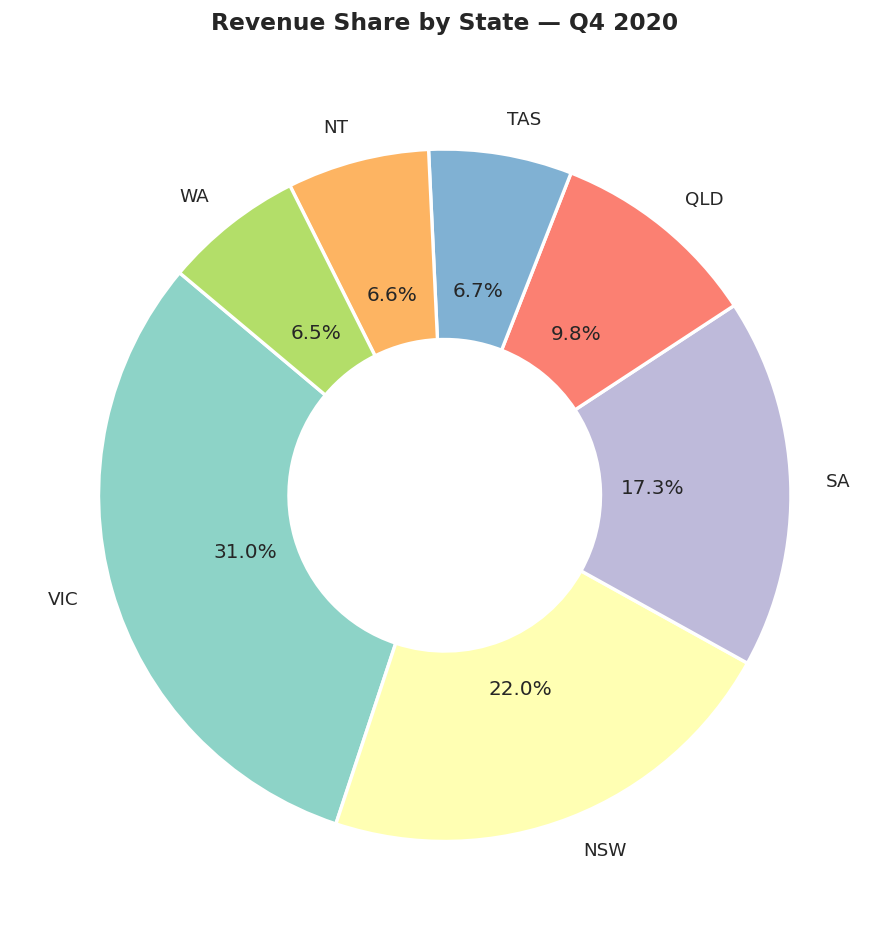

In [15]:
# Pie chart — Revenue share by state
fig, ax = plt.subplots(figsize=(8, 8))
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
ax.pie(state_sales['Total_Sales'],
       labels=state_sales['State'],
       autopct='%1.1f%%',
       startangle=140,
       wedgeprops=wedge_props,
       colors=sns.color_palette('Set3', len(state_sales)))
ax.set_title('Revenue Share by State — Q4 2020', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('pie_revenue_share.png', bbox_inches='tight')
plt.show()

## 9. Top & Bottom Performing States

In [16]:
top3 = state_sales.head(3)
bottom3 = state_sales.tail(3)

print('=== TOP 3 REVENUE-GENERATING STATES ===')
print(top3[['State', 'Total_Sales_M', 'Revenue_Share_%', 'Avg_Sales']].to_string(index=False))

print('\n=== BOTTOM 3 REVENUE-GENERATING STATES ===')
print(bottom3[['State', 'Total_Sales_M', 'Revenue_Share_%', 'Avg_Sales']].to_string(index=False))

=== TOP 3 REVENUE-GENERATING STATES ===
State  Total_Sales_M  Revenue_Share_%    Avg_Sales
  VIC         105.56            31.02 97745.370370
  NSW          74.97            22.03 69416.666667
   SA          58.86            17.30 54497.685185

=== BOTTOM 3 REVENUE-GENERATING STATES ===
State  Total_Sales_M  Revenue_Share_%    Avg_Sales
  TAS          22.76             6.69 21074.074074
   NT          22.58             6.64 20907.407407
   WA          22.15             6.51 20511.574074


In [17]:
# Detailed breakdown for bottom states — find strongest segment to target
bottom_states = bottom3['State'].tolist()
bottom_df = df[df['State'].isin(bottom_states)]

bottom_group = (
    bottom_df.groupby(['State', 'Group'])['Sales']
    .sum()
    .reset_index()
    .sort_values(['State', 'Sales'], ascending=[True, False])
)

print('=== BEST CUSTOMER GROUP IN LOWER-REVENUE STATES ===')
print(bottom_group.to_string(index=False))

=== BEST CUSTOMER GROUP IN LOWER-REVENUE STATES ===
State   Group   Sales
   NT     Men 5762500
   NT    Kids 5700000
   NT   Women 5652500
   NT Seniors 5465000
  TAS    Kids 5775000
  TAS     Men 5757500
  TAS Seniors 5650000
  TAS   Women 5577500
   WA     Men 5752500
   WA    Kids 5625000
   WA Seniors 5512500
   WA   Women 5262500


## 10. Correlation & Pivot Summary

In [18]:
# Full pivot table: State × Group × Time
pivot_full = pd.pivot_table(
    df,
    values='Sales',
    index='State',
    columns=['Group', 'Time'],
    aggfunc='sum',
    fill_value=0
)

print('Full Pivot Table (Sales by State, Group & Time):')
pivot_full

Full Pivot Table (Sales by State, Group & Time):


Group      Kids                         Men                     Seniors  \
Time  Afternoon  Evening  Morning Afternoon  Evening  Morning Afternoon   
State                                                                     
NSW     6187500  6132500  6267500   6512500  6220000  6290000   5985000   
NT      1880000  1972500  1847500   1885000  1915000  1962500   1797500   
QLD     2860000  2715000  2935000   3007500  2540000  2845000   2840000   
SA      4970000  4797500  4747500   4760000  4942500  4952500   5092500   
TAS     1872500  1975000  1927500   2030000  1842500  1885000   1880000   
VIC     8787500  8622500  8950000   8690000  8900000  8817500   8830000   
WA      1945000  1837500  1842500   1882500  1862500  2007500   1770000   

Group                       Women                    
Time   Evening  Morning Afternoon  Evening  Morning  
State                                                
NSW    6032500  6170000   6425000  6327500  6420000  
NT     1907500  1760000   1947500  1832500  1872500  
QLD    2592500  2757500   2640000  2785000  2900000  
SA     4660000  4965000   5202500  4967500  4800000  
TAS    1855000  1915000   1887500  1892500  1797500  
VIC    8427500  9057500   8755000  8930000  8797500  
WA     1792500  1950000   1685000  1810000  1767500

Correlation — Units vs Sales:
       Unit  Sales
Unit    1.0    1.0
Sales   1.0    1.0


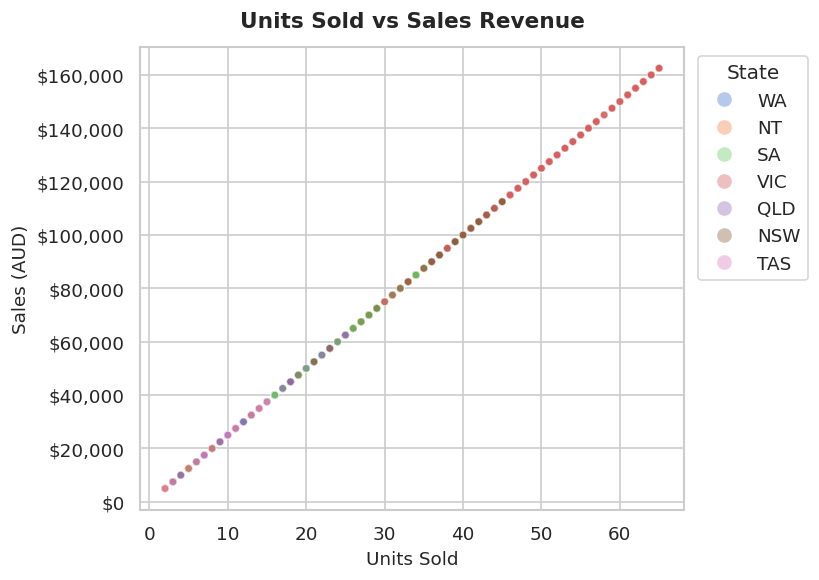

In [19]:
# Correlation between Units sold and Sales revenue
print('Correlation — Units vs Sales:')
print(df[['Unit', 'Sales']].corr())

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='Unit', y='Sales', hue='State', alpha=0.4, ax=ax, s=20)
ax.set_title('Units Sold vs Sales Revenue', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Units Sold', fontsize=11)
ax.set_ylabel('Sales (AUD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.savefig('scatter_units_sales.png', bbox_inches='tight')
plt.show()

## 11. Key Insights & Business Recommendations

### 📊 Key Findings

**High-Revenue States:**
- The top revenue-generating states contribute the largest share of AAL's Q4 2020 sales. These states should be prioritized for inventory restocking, new store openings, and premium product launches.

**Lower-Revenue States:**
- States at the bottom of the revenue ladder present significant growth opportunities. Their lower performance may be attributed to lower population density, lack of marketing presence, or fewer store locations.

**Customer Group Insights:**
- Seniors and Women consistently contribute strong revenues across most states. Kids and Men segments show opportunities for targeted promotional campaigns.

**Time-of-Day Insights:**
- Evening shopping tends to show strong performance — this suggests promotional events, flash sales, or extended store hours in the evenings could drive incremental revenue.

**Monthly Trends:**
- December shows the highest sales across all states due to holiday season demand — a strong signal to amplify festive season campaigns.

---

### ✅ Recommendations for AAL S&M Leadership

| Action | Target | Detail |
|--------|--------|--------|
| **Invest & Expand** | Top 2–3 states | Open additional outlets; increase SKU diversity |
| **Targeted Campaigns** | Bottom 3 states | Geo-targeted digital ads; influencer tie-ups |
| **Loyalty Programs** | All states | Reward repeat customers in every age group |
| **Evening Flash Sales** | Low-revenue states | Drive footfall during peak evening hours |
| **Festive Push** | All states | Amplify December promotions; pre-order campaigns |
| **Segment Focus** | Lower states | Prioritize best-performing group per state |

---
*Analysis prepared for AAL Sales & Marketing Department — Q4 2020 Data (Oct–Dec 2020)*